In [1]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from GNN import GNN
from tree import Node, Tree
from homomorphism import total_hom, total_hom_preprocess, refine_colours

In [2]:
def fb_test():
    with open("edges.pkl", "rb") as f:
        edges = pickle.load(f)
    
    G = GNN(edges=edges, directed=False)

    return G

In [3]:
trees = list(nx.generators.nonisomorphic_trees(7))

In [4]:
G = fb_test()

arr = []

"""

for i in range(len(trees)):
    print(f"Computing Tree {i}")
    T = Tree(edges=trees[i].edges)
    T = T.nodes[1]
    arr.append(total_hom(T, G))

print(arr)
"""

'\n\nfor i in range(len(trees)):\n    print(f"Computing Tree {i}")\n    T = Tree(edges=trees[i].edges)\n    T = T.nodes[1]\n    arr.append(total_hom(T, G))\n\nprint(arr)\n'

In [5]:
deltas = {i: [] for i in range(len(trees))}
A, colour_count = refine_colours(G)

In [6]:
for i in range(10):
    print(f"Processing Iteration #{i + 1}...")
    for index, tree in enumerate(trees):
        delta = time.time()
        tree = Tree(edges=list(trees[index].edges))
        tree = tree.nodes[1]
        total_hom_preprocess(tree, G, colour_count, A)
        delta = time.time() - delta
        deltas[index].append(delta)
    print(f"Completed Iteration #{i + 1}!")

Processing Iteration #1...
Completed Iteration #1!
Processing Iteration #2...
Completed Iteration #2!
Processing Iteration #3...
Completed Iteration #3!
Processing Iteration #4...
Completed Iteration #4!
Processing Iteration #5...
Completed Iteration #5!
Processing Iteration #6...
Completed Iteration #6!
Processing Iteration #7...
Completed Iteration #7!
Processing Iteration #8...
Completed Iteration #8!
Processing Iteration #9...
Completed Iteration #9!
Processing Iteration #10...
Completed Iteration #10!


In [7]:
new_deltas = deltas.copy()
for i in range(len(new_deltas)):
    new_deltas[i] = np.array(new_deltas[i]).mean()

In [8]:
new_deltas

{0: np.float64(0.02356743812561035),
 1: np.float64(0.02276113033294678),
 2: np.float64(0.02283506393432617),
 3: np.float64(0.022209644317626953),
 4: np.float64(0.022461938858032226),
 5: np.float64(0.02257382869720459),
 6: np.float64(0.022012090682983397),
 7: np.float64(0.022464346885681153),
 8: np.float64(0.022592687606811525),
 9: np.float64(0.022896480560302735),
 10: np.float64(0.022553348541259767)}

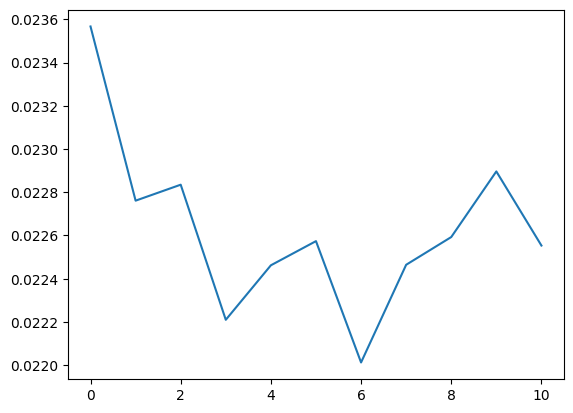

In [9]:
import matplotlib.pyplot as plt

x = list(new_deltas.keys())
y = list(new_deltas.values())

plt.plot(x, y)

In [10]:
with open("lanzinger_barcelo_results.pkl", "wb") as f:
    pickle.dump((x, y), f)

In [11]:
with open("lanzinger_barcelo_results.pkl", "rb") as f:
    results1 = pickle.load(f)

with open("pact_bench_data.pkl", "rb") as f:
    results2 = pickle.load(f)

Text(0, 0.5, 'Time (s)')

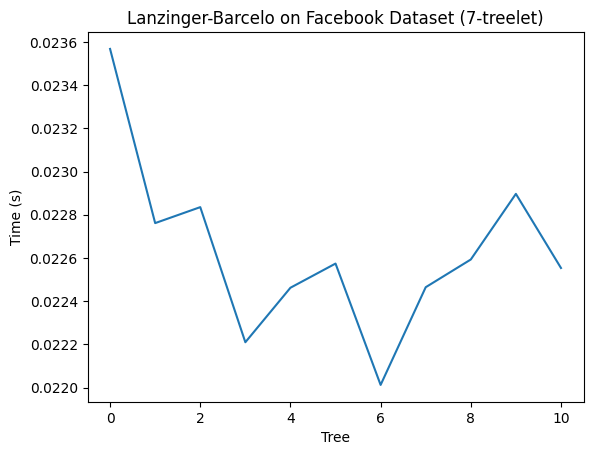

In [12]:
x1, y1 = results1
plt.plot(x1, y1)
plt.title("Lanzinger-Barcelo on Facebook Dataset (7-treelet)")
plt.xlabel("Tree")
plt.ylabel("Time (s)")

Text(0, 0.5, 'Time (s)')

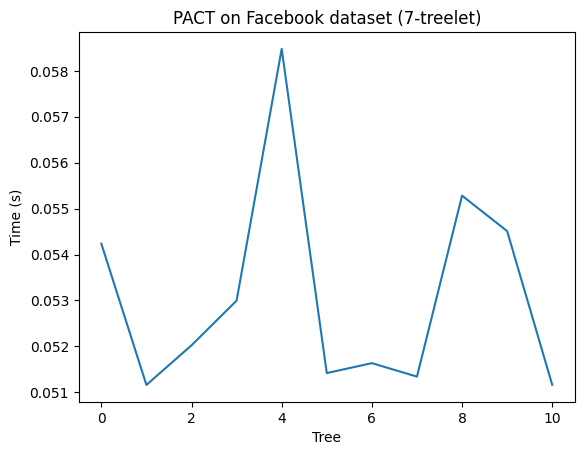

In [13]:
x2, y2 = results2
plt.plot(x2, y2)
plt.title("PACT on Facebook dataset (7-treelet)")
plt.xlabel("Tree")
plt.ylabel("Time (s)")

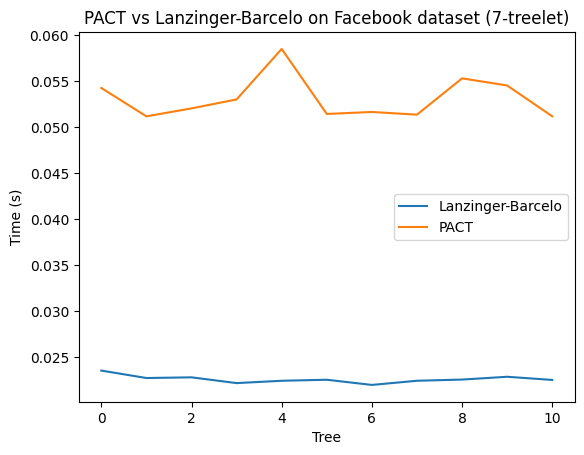

In [14]:
plt.plot(x1, y1, label="Lanzinger-Barcelo")
plt.plot(x2, y2, label="PACT")
plt.xlabel("Tree")
plt.ylabel("Time (s)")
plt.title("PACT vs Lanzinger-Barcelo on Facebook dataset (7-treelet)")
plt.legend()

In [15]:
import pandas as pd

df_1 = pd.DataFrame({
    'Tree': x1,
    'Lanzinger-Barcelo': y1,
    'PACT': y2
})

df_1.to_csv('lanzinger_pact_fb_k7.csv', index=False)

In [16]:
with open("pact_bench_data_regular.pkl", "rb") as f:
    results_regular_pact = pickle.load(f)

In [17]:
x1, y1 = results_regular_pact

Text(0.5, 1.0, 'PACT on regular graph (7-treelet)')

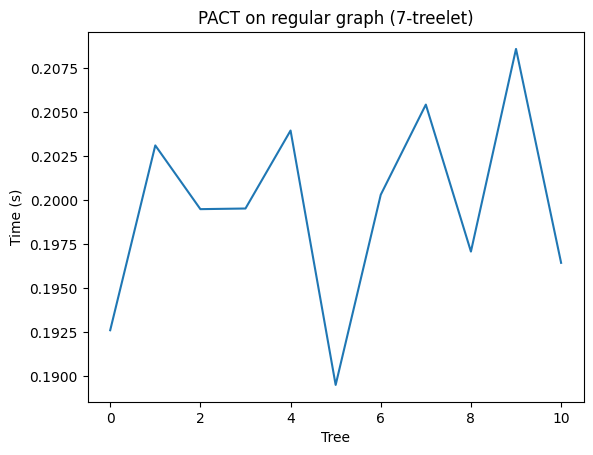

In [18]:
plt.plot(x1, y1)
plt.xlabel("Tree")
plt.ylabel("Time (s)")
plt.title("PACT on regular graph (7-treelet)")

In [19]:
with open("lanzinger_barcelo_results_regular.pkl", "rb") as f:
    results_regular_lanzinger = pickle.load(f)

Text(0.5, 1.0, 'Lanzinger-Barcelo on regular graph (7-treelet)')

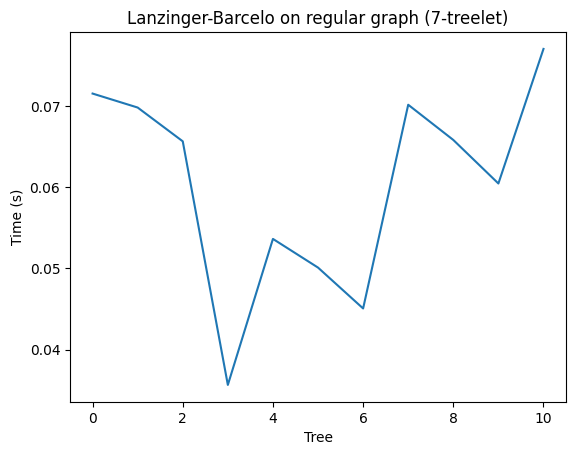

In [20]:
x2, y2 = results_regular_lanzinger

plt.plot(x2, y2)
plt.xlabel("Tree")
plt.ylabel("Time (s)")
plt.title("Lanzinger-Barcelo on regular graph (7-treelet)")

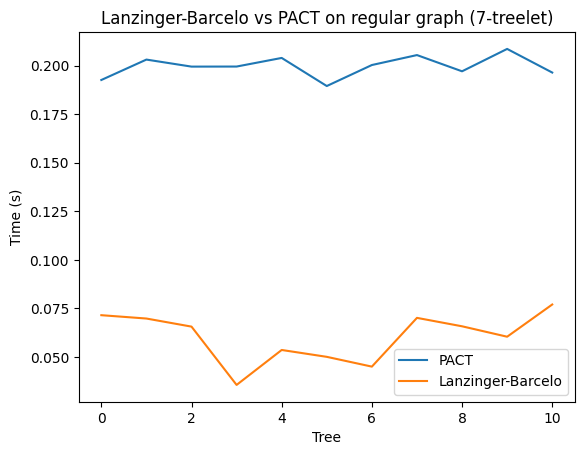

In [21]:
x1, y1 = results_regular_pact
x2, y2 = results_regular_lanzinger

plt.plot(x1, y1, label="PACT")
plt.plot(x2, y2, label="Lanzinger-Barcelo")
plt.xlabel("Tree")
plt.ylabel("Time (s)")
plt.title("Lanzinger-Barcelo vs PACT on regular graph (7-treelet)")
plt.legend()

In [22]:
df_2 = pd.DataFrame({
    'Tree': x1,
    'Lanzinger-Barcelo': y2,
    'PACT': y1
})

df_2.to_csv("lanzinger_pact_regular_k7.csv")

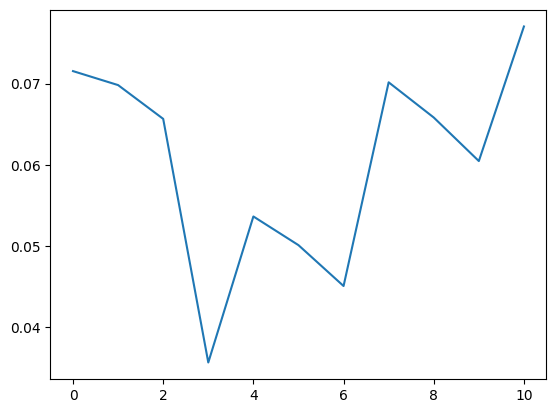

In [23]:
plt.plot(df_2["Tree"], df_2["Lanzinger-Barcelo"])

In [24]:
print(f"LB Mean: {df_1["Lanzinger-Barcelo"].mean()}")
print(f"PACT Mean: {df_1["PACT"].mean()}")

LB Mean: 0.02262981804934415
PACT Mean: 0.05311295769431375


In [25]:
print(f"LB Mean: {df_2["Lanzinger-Barcelo"].mean()}")
print(f"PACT Mean: {df_2["PACT"].mean()}")

LB Mean: 0.06044922525232488
PACT Mean: 0.19964046911759814
